In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Your Name and PRN:
- Name: ______________________
- PRN : ______________________
- Date: ______________________

# Deep Neural Network
## Assignment A06

## Torch
- Select number of layers
- Select node in each of the layers
- Choose activation function
- multi-class - Fashion MNIST dataset (all 60000 images)
- Implement one or more of following to achieve max accuracy.
    - L1/ L2 Regularization
    - Dropout
    - Batch Normalization
    - Early stopping
- Save model

In [2]:
###-----------------
### Import Libraries
###-----------------

import os
import numpy as np
import pandas as pd

from collections.abc import Callable
from typing import Literal


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, Dataset

from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix

In [3]:
###-----------------
### Global Variables
###-----------------
# inpDir = os.path.join('..', '..', 'input')
# outDir = '../output'
# modelDir = '../models'
# subDir = 'fashion_mnist'
# altName = 'A04_fashion_vanila'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible results
torch.manual_seed(RANDOM_STATE)

# parameters for Matplotlib
params = {'legend.fontsize': 'large',
          'figure.figsize': (15, 8),
          'axes.labelsize': 'large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'large',
          'ytick.labelsize':'large'
         }

CMAP = 'brg' # plt.cm.Spectral

plt.rcParams.update(params)


In [4]:
###-----------------
### Hyper Parameters
###-----------------
EPOCHS = 30 # number of epochs
ALPHA = 0.001 # learning rate
BATCH_SIZE = 64 # mini batch size (number of rows)
TRAIN_SIZE = int(18 * BATCH_SIZE)
TEST_SIZE = 0.2
WEIGHT_DECAY = 0.001
PATIENCE = 20
LR_FACTOR = 0.1
LR_PATIENCE = 5
MIN_LR = 1e-6

## Load Fashion MNIST dataset

This guide uses the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits (0, 1, 2, etc.) in a format identical to that of the articles of clothing you'll use here.

This guide uses Fashion MNIST for variety, and because it's a slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithm works as expected. They're good starting points to test and debug code.

Here, 60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images. You can access the Fashion MNIST directly from TensorFlow. Import and [load the Fashion MNIST data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data) directly from TensorFlow:

In [5]:
train_filename = './input/fashion-mnist_train.csv'
test_filename = './input/fashion-mnist_test.csv'

train_df = pd.read_csv(train_filename, header = 0)
test_df = pd.read_csv(test_filename, header = 0)

train_df.shape, test_df.shape

((60000, 785), (10000, 785))

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Each image is mapped to a single label. Since the *class names* are not included with the dataset, store them here to use later when plotting the images:

In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
              'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

class_names = {0: 'T-shirt/top',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',
               5:'Sandal', 6: 'Shirt',7: 'Sneaker', 8:'Bag', 9: 'Ankle boot'}

In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 59.9 MB


In [8]:
train_df.isna().sum().sum(), test_df.isna().sum().sum()

(np.int64(0), np.int64(0))

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [10]:
# make sure that there will be only one StandardScaler   --- Singleton Class. 
# Cannot create two objects of this class
class GlobalScaler:
    _instance = None # single underscore _ does not mean anything, just for convention <Glo........>

    def __init__(self):
        if GlobalScaler._instance is not None:
            raise Exception ('GlobalScaler is Singleton Class')
        
        self.scaler = StandardScaler()

    # singleton pattern --- not instantiating using GlobalScaler()
    @classmethod
    def get_instance(cls):
        if cls._instance is None:
            cls._instance = GlobalScaler()
        return cls._instance

In [11]:

class FashionDS(Dataset):
    global_scaler = GlobalScaler.get_instance() # protected variable _instance, so use getter

    def __init__(self, dataframe, device = device, 
                        is_train = True, label_col = None):
        self.df = dataframe
        self.device = device
        self.is_train = is_train
        self.scaler = self.global_scaler.scaler   # we can use FifaDS.global_scaler in place of self.global_scaler
        self.label_col = label_col
    
        self.labels = self.df[label_col].to_numpy()  # dataframe to numpy
        
        if self.is_train:
            X = self.df.drop(label_col, axis=1)            
            self.features = self.scaler.fit_transform(X)
        else:           
            X = self.df.drop(label_col, axis=1)          # for testing data
            self.features = self.scaler.transform(X)    
        
    def __len__(self): # len of dataframe
        return len(self.features)
    
    def __getitem__(self, index): # return torch tensor
        feature = self.features[index]
        label = self.labels[index]

        feature = torch.tensor(feature, dtype=torch.float32, device=self.device)
        label = torch.tensor(label, dtype=torch.int64, device=device)
        return feature, label
    
    

In [12]:
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [13]:
label_col = 'label'
train_ds = FashionDS(train_df, is_train=True, label_col=label_col)
test_ds = FashionDS(test_df, is_train=False, label_col=label_col)

In [14]:
type(train_df), type(train_ds), type(test_df), type(test_ds)

(pandas.core.frame.DataFrame,
 __main__.FashionDS,
 pandas.core.frame.DataFrame,
 __main__.FashionDS)

In [15]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True) # dataloader will give batches
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True)

In [16]:
class Model(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        dor1 = 0.1
        dor2 = 0.2
        dor3 = 0.3
        dor4 = 0.4


        # first layer  -- gets input
        out_dim_1 = 584
        self.layer1 = nn.Linear(input_dim, out_dim_1)   # output 584
        self.bn1 = nn.BatchNorm1d(out_dim_1)    # batchnorm
        self.actv1 = nn.ReLU()
        self.do1 = nn.Dropout(dor1)  # dropout

        # second layer
        out_dim_2 = 384
        self.layer2 = nn.Linear(out_dim_1, out_dim_2)   # output 384
        self.bn2 = nn.BatchNorm1d(out_dim_2)
        self.actv2 = nn.ReLU()
        self.do2 = nn.Dropout(dor2)

        # third layer
        out_dim_3 = 192
        self.layer3 = nn.Linear(out_dim_2, out_dim_3)   # output 192
        self.bn3 = nn.BatchNorm1d(out_dim_3)
        self.actv3 = nn.ReLU()
        self.do3 = nn.Dropout(dor3)

        # fourth layer
        out_dim_4 = 90
        self.layer4 = nn.Linear(out_dim_3, out_dim_4)   # output 90
        self.bn4 = nn.BatchNorm1d(out_dim_4)
        self.actv4 = nn.ReLU()
        self.do4 = nn.Dropout(dor4)

        # fifth layer -- gives outputs
        self.layer5 = nn.Linear(out_dim_4, 10)           # output 10

    
    # forward propagation
    def forward(self, x):

        x = self.layer1(x)  # aggregation
        x = self.bn1(x)  # batch normalization
        x = self.actv1(x)   # activation
        x = self.do1(x)   # dropout

        x = self.layer2(x)
        x = self.bn2(x)
        x = self.actv2(x)
        x = self.do2(x)

        x = self.layer3(x)
        x = self.bn3(x)
        x = self.actv3(x)
        x = self.do3(x)

        x = self.layer4(x)
        x = self.bn4(x)
        x = self.actv4(x)
        x = self.do4(x)


        x = self.layer5(x)
        return x
    

model = Model(input_dim=784).to(device=device)
print(model)
        

Model(
  (layer1): Linear(in_features=784, out_features=584, bias=True)
  (bn1): BatchNorm1d(584, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (actv1): ReLU()
  (do1): Dropout(p=0.1, inplace=False)
  (layer2): Linear(in_features=584, out_features=384, bias=True)
  (bn2): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (actv2): ReLU()
  (do2): Dropout(p=0.2, inplace=False)
  (layer3): Linear(in_features=384, out_features=192, bias=True)
  (bn3): BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (actv3): ReLU()
  (do3): Dropout(p=0.3, inplace=False)
  (layer4): Linear(in_features=192, out_features=90, bias=True)
  (bn4): BatchNorm1d(90, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (actv4): ReLU()
  (do4): Dropout(p=0.4, inplace=False)
  (layer5): Linear(in_features=90, out_features=10, bias=True)
)


Torch does not have L1 and L2, we can use them via weight decay in optimizer.

In [17]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=ALPHA, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,
                                                       min_lr=MIN_LR,
                                                       mode='min', factor=LR_FACTOR, 
                                                       patience=PATIENCE)

loss, test_loss = [], []
acc, test_acc = [], []
n_epoch = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    for i, data in enumerate(train_loader):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        batch_loss = loss_fn(outputs, labels)
        batch_acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())

        batch_loss.backward()
        optimizer.step()
        train_loss += batch_loss.item() * inputs.size(0)
        train_acc += batch_acc * inputs.size(0)

    train_loss = train_loss/len(train_ds)
    train_acc = train_acc/len(train_ds)
    loss.append(train_loss)
    acc.append(train_acc)


    # testing now
    with torch.no_grad():
        model.eval()
        tst_loss = 0.0
        tst_acc = 0.0

        for i, data in enumerate(test_loader):
            inputs, labels = data
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            batch_loss = loss_fn(outputs, labels)
            batch_acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())

            tst_loss += batch_loss.item() * inputs.size(0)
            tst_acc += batch_acc * inputs.size(0)

        tst_loss = tst_loss/len(test_ds)
        tst_acc = tst_acc/len(test_ds)
        test_loss.append(tst_loss)
        test_acc.append(tst_acc)

    n_epoch.append(epoch)

    scheduler.step(tst_loss)

    if epoch%10 == 0: 
        print(f'Epoch {epoch}: loss = {train_loss:.4f}, accuracy = {train_acc:.3f}'+
                        f', val_loss = {tst_loss:.4f}, val_accuracy = {tst_acc:.3f}')
        
        

Epoch 0: loss = 0.5669, accuracy = 0.811, val_loss = 0.3755, val_accuracy = 0.863
Epoch 10: loss = 0.2544, accuracy = 0.909, val_loss = 0.2840, val_accuracy = 0.899
Epoch 20: loss = 0.1892, accuracy = 0.932, val_loss = 0.2806, val_accuracy = 0.904


### Train pred

In [18]:
# y_true, y_pred= [], []
# for feature, label in train_ds:
#     pred = model(feature).numpy()
#     y_true.extend(label)
#     y_pred.extend(pred.argmax(axis=1))

# print(classification_report(y_true, y_pred))

### Test pred

In [25]:
y_true, y_pred = [], []

for feature, label in test_loader:
    pred = model(feature).detach().cpu().numpy()
    y_true.extend(label)
    y_pred.extend(pred.argmax(axis=1))

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1000
           1       0.98      0.99      0.99      1000
           2       0.82      0.88      0.85      1000
           3       0.92      0.92      0.92      1000
           4       0.87      0.85      0.86      1000
           5       0.99      0.94      0.96      1000
           6       0.80      0.72      0.76      1000
           7       0.93      0.95      0.94      1000
           8       0.98      0.98      0.98      1000
           9       0.94      0.98      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



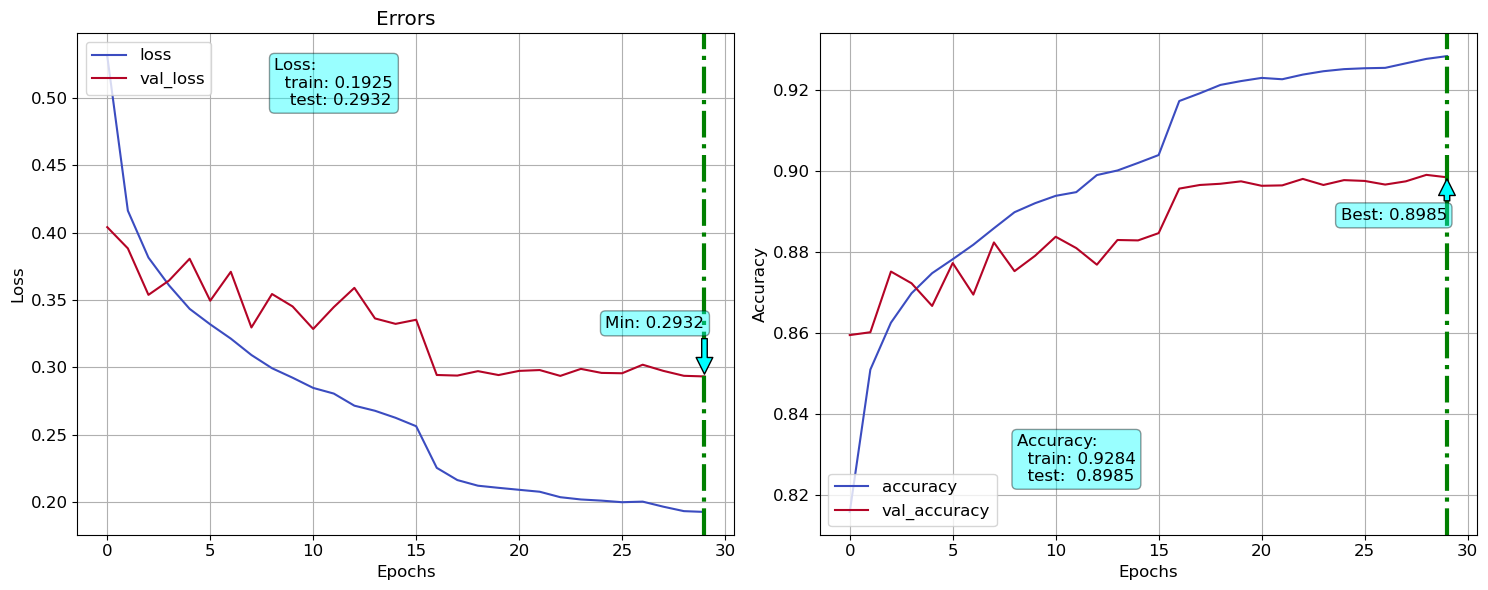

In [ ]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

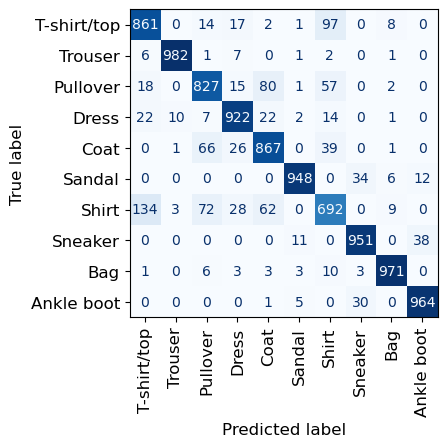

In [ ]:
fn_plot_confusion_matrix(y_true, y_pred, class_names)

C:\Users\dai\AppData\Local\Temp\ipykernel_20220\390684749.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(2,4, str(row[0]), color='b', fontsize=14)
C:\Users\dai\AppData\Local\Temp\ipykernel_20220\390684749.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(10,25, class_names[row[0]], color='r', fontsize=10)


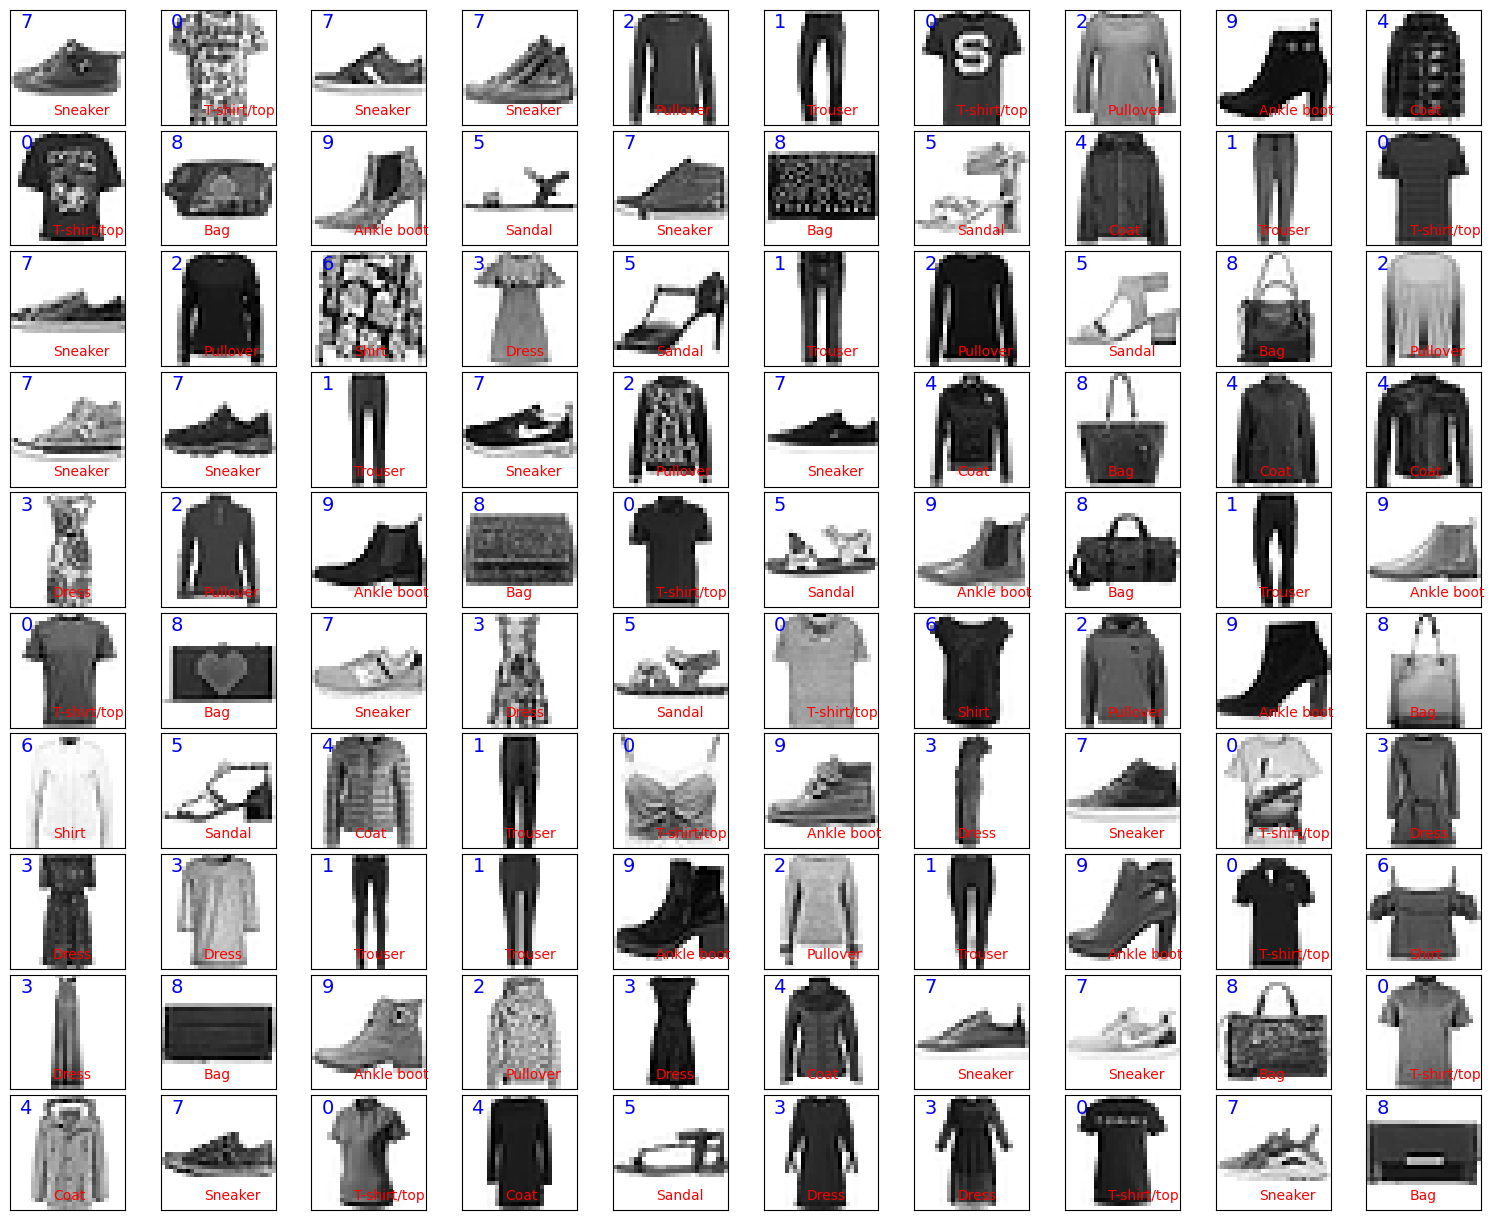

In [ ]:
plot_df = train_df.sample(n=100)
fig = plt.figure(figsize=(15,12))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

i=0
for _, row in plot_df.iterrows():
    i = i + 1
    image = row.values[1:].reshape(28,28)
    ax = fig.add_subplot(10, 10, (i), xticks=[], yticks=[])
    ax.imshow(image, cmap=plt.cm.binary, interpolation='nearest')
    ax.text(2,4, str(row[0]), color='b', fontsize=14)
    ax.text(10,25, class_names[row[0]], color='r', fontsize=10)
plt.show()